1. Preprocesamiento de Datos

En esta etapa limpiamos los datos, manejamos los valores nulos y eliminamos columnas que no aportan valor analítico (como el número de fila). Aquí no convertiremos las variables de texto a números (One-Hot Encoding) ni escalaremos los datos, ya que mantenerlos en su formato original facilita la interpretación de los gráficos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")

# 1. Cargar el dataset
df = pd.read_csv('dataset_crediticio_chile-1-1.csv')

# 2. Eliminar identificadores que no sirven para el análisis
df = df.drop(columns=['No.'], errors='ignore')

# 3. Manejo de valores nulos
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(exclude=[np.number]).columns

# Imputar nulos: mediana para numéricos, moda para categóricos
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Formato del dataset tras preprocesamiento:", df.shape)

Formato del dataset tras preprocesamiento: (4266, 20)


C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_20224\889040709.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_20224\889040709.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

2. Análisis Exploratorio de Datos (EDA)

Aquí buscamos entender las estadísticas descriptivas básicas del conjunto de datos (medias, valores mínimos, máximos) y cómo se distribuyen las categorías.

In [2]:
# 1. Resumen estadístico de las variables numéricas
print("Resumen Estadístico (Numéricas):")
display(df.describe().apply(lambda s: s.apply('{0:.2f}'.format)))

# 2. Resumen de variables categóricas
print("\nResumen de Variables Categóricas:")
display(df.describe(include=['object']))

# 3. Proporción de la variable objetivo (Riesgo Alto vs Bajo)
print("\nDistribución de Riesgo Crediticio:")
print(df['RiesgoAlto'].value_counts(normalize=True) * 100)

Resumen Estadístico (Numéricas):


,Tiene_Vehiculo,Edad,Num_Entidades_Deuda,Tiene_Tarjeta,Saldo_Tarjeta_CLP,Saldo_Total_CLP,Variacion_Endeudamiento,Peor_Calificacion_36M,Peor_Calificacion_12M,Reportes_Central_36M,Reportes_Central_12M,Promedio_Saldo_CLP,Maximo_Saldo_CLP,Ingreso_CLP,Ratio_Saldo_Ingreso,ScoreRiesgo,RiesgoAlto
count,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00
mean,0.14,40.83,1.74,0.43,1077308.26,4074351.50,-0.04,1.04,0.19,27.39,10.71,3818433.37,6203071.20,2273164.33,0.17,8.19,0.25
std,0.34,11.78,1.09,0.50,2370446.16,5247420.19,5.61,1.36,0.47,9.36,2.84,4636673.42,7084091.78,2087078.98,0.22,5.44,0.43
min,0.00,22.00,0.00,0.00,0.00,0.00,-1.00,0.00,0.00,0.00,0.00,0.00,0.00,170000.00,0.00,0.00,0.00
25%,0.00,31.00,1.00,0.00,0.00,840416.25,-0.50,0.00,0.00,21.00,11.00,1223747.49,2125000.00,1300500.00,0.04,3.74,0.00
50%,0.00,39.00,2.00,0.00,0.00,2343212.00,-0.22,1.00,0.00,30.00,12.00,2449474.41,4250000.00,1819000.00,0.10,7.41,0.00
75%,0.00,50.00,2.00,1.00,1016281.25,5406620.50,-0.02,1.00,0.00,36.00,12.00,4807140.25,8014059.25,2550000.00,0.23,11.21,0.00
max,1.00,70.00,6.00,1.00,24341543.50,78859600.00,273.03,4.00,4.00,36.00,12.00,77011547.51,127076419.50,59500000.00,5.88,40.07,1.00



Resumen de Variables Categóricas:


,Sexo,Tipo_Empleo,Ciudad_Chile
count,4266,4266,4266
unique,2,2,7
top,M,IND,SANTIAGO
freq,2151,2671,3670



Distribución de Riesgo Crediticio:
RiesgoAlto
0    75.035162
1    24.964838
Name: proportion, dtype: float64


3. Visualización de Datos

Estos bloques de código generarán los gráficos clave para entender el comportamiento de los clientes y qué variables parecen tener relación con el riesgo crediticio.

Gráfico 1: Distribución del Riesgo (Desbalanceo de clases)

C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_20224\1824147398.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='RiesgoAlto', palette=['#2ecc71', '#e74c3c'])


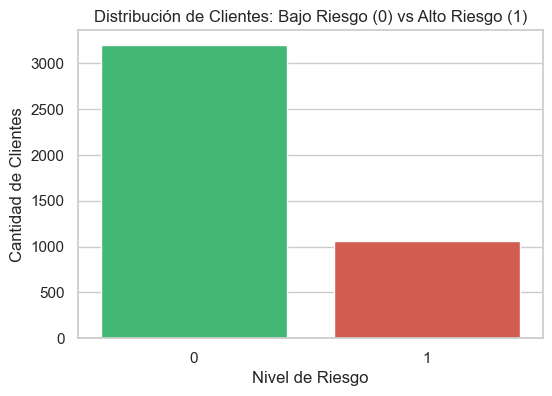

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='RiesgoAlto', palette=['#2ecc71', '#e74c3c'])
plt.title('Distribución de Clientes: Bajo Riesgo (0) vs Alto Riesgo (1)')
plt.xlabel('Nivel de Riesgo')
plt.ylabel('Cantidad de Clientes')
plt.show()

Gráfico 2: Variables Demográficas vs Riesgo

Analizaremos cómo se distribuye el riesgo según el sexo y si el cliente tiene vehículo.

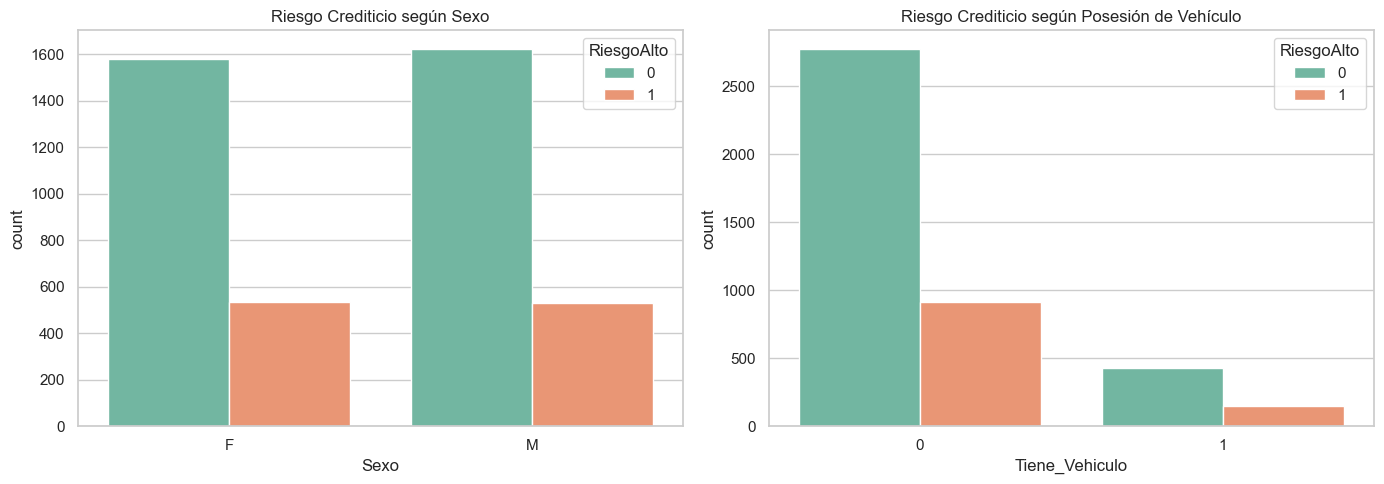

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='Sexo', hue='RiesgoAlto', ax=axes[0], palette='Set2')
axes[0].set_title('Riesgo Crediticio según Sexo')

sns.countplot(data=df, x='Tiene_Vehiculo', hue='RiesgoAlto', ax=axes[1], palette='Set2')
axes[1].set_title('Riesgo Crediticio según Posesión de Vehículo')

plt.tight_layout()
plt.show()

Gráfico 3: Distribución de Edad e Ingresos

Usaremos diagramas de caja (Boxplots) para ver si los clientes de alto riesgo tienden a ser más jóvenes o a tener menores ingresos.

C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_20224\1924644153.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='RiesgoAlto', y='Edad', ax=axes[0], palette='pastel')
C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_20224\1924644153.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='RiesgoAlto', y='Ingreso_CLP', ax=axes[1], palette='pastel')


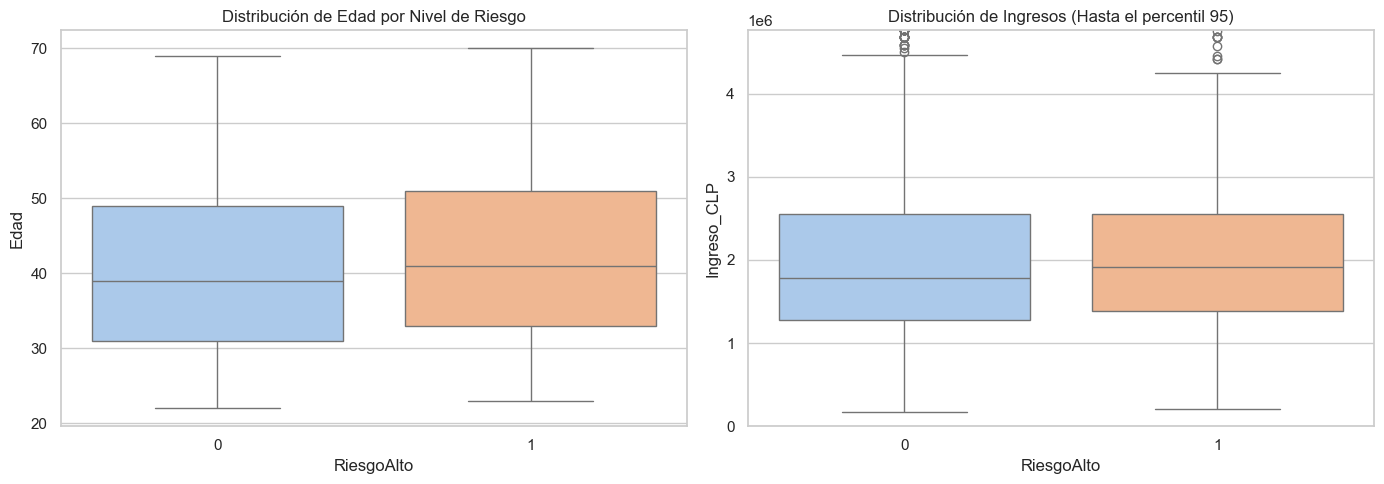

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='RiesgoAlto', y='Edad', ax=axes[0], palette='pastel')
axes[0].set_title('Distribución de Edad por Nivel de Riesgo')

sns.boxplot(data=df, x='RiesgoAlto', y='Ingreso_CLP', ax=axes[1], palette='pastel')
# Limitamos el eje Y en los ingresos para evitar que los valores atípicos (muy millonarios) deformen el gráfico
axes[1].set_ylim(0, df['Ingreso_CLP'].quantile(0.95)) 
axes[1].set_title('Distribución de Ingresos (Hasta el percentil 95)')

plt.tight_layout()
plt.show()

Gráfico 4: Comportamiento Financiero

Analizamos la cantidad de deudas activas y los reportes negativos.

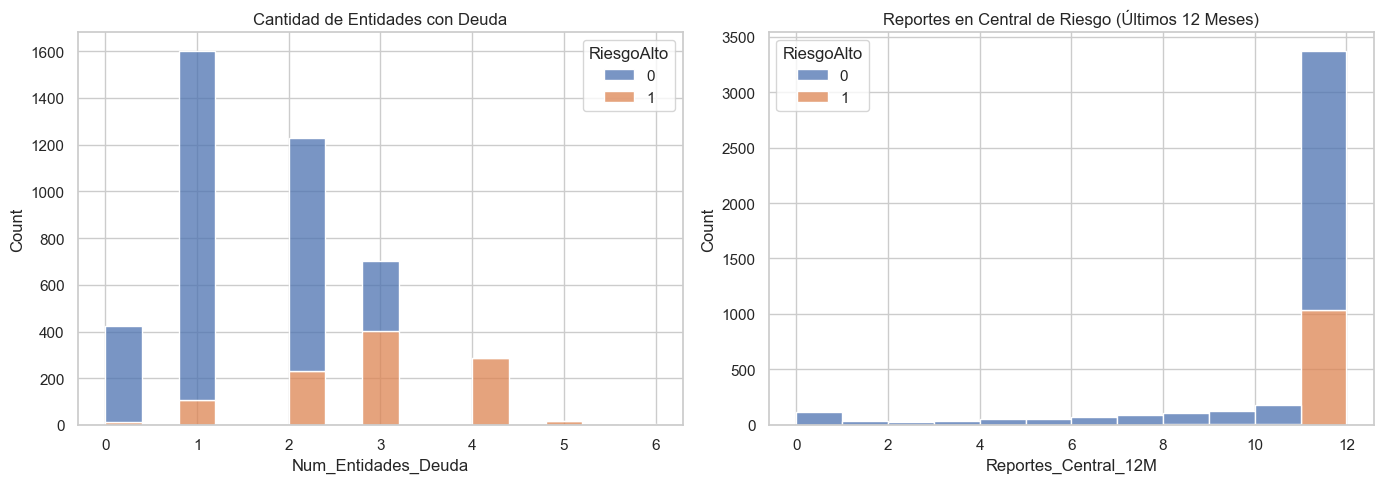

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='Num_Entidades_Deuda', hue='RiesgoAlto', multiple="stack", bins=15, ax=axes[0])
axes[0].set_title('Cantidad de Entidades con Deuda')

sns.histplot(data=df, x='Reportes_Central_12M', hue='RiesgoAlto', multiple="stack", bins=12, ax=axes[1])
axes[1].set_title('Reportes en Central de Riesgo (Últimos 12 Meses)')

plt.tight_layout()
plt.show()

Gráfico 5: Matriz de Correlación

Este gráfico es vital en el EDA. Muestra cómo se relacionan las variables numéricas entre sí. Tonos más oscuros o intensos indican una fuerte relación (positiva o negativa).

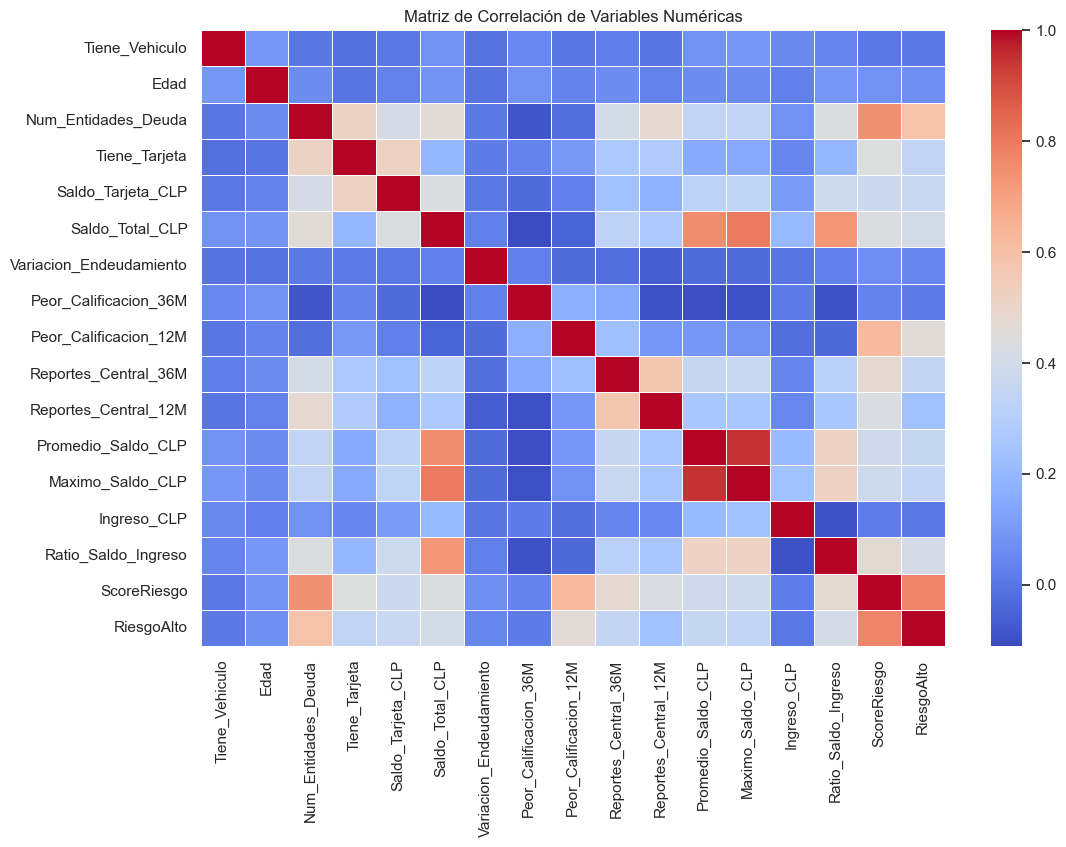

In [7]:
plt.figure(figsize=(12, 8))
# Seleccionamos solo las numéricas para la correlación
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Generamos un mapa de calor (Heatmap)
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()